In [1]:
!pip -q install datasets

In [2]:
from datasets import load_dataset
languages = ["java", "python", "javascript", "go"]

datasets = {}

for lang in languages:
    print(f"Downloading {lang}...")
    datasets[lang] = load_dataset(
        "code_search_net",
        lang,
        split="train"
    )

print("Done!")

README.md: 0.00B [00:00, ?B/s]

java/train-00000-of-00001.parquet:   0%|          | 0.00/390M [00:00<?, ?B/s]

java/test-00000-of-00001.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

java/validation-00000-of-00001.parquet:   0%|          | 0.00/12.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/454451 [00:00<?, ? examples/s]

...

go/validation-00000-of-00001.parquet:   0%|          | 0.00/7.59M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/317832 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/14291 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/14242 [00:00<?, ? examples/s]

Done!


In [3]:
from datasets import load_dataset, concatenate_datasets

languages = ["java", "python", "javascript", "go"]
sample_size = 500

all_datasets = []

for lang in languages:
    print(f"Downloading {lang}...")

    ds = load_dataset(
        "code_search_net",
        lang,
        split="train"
    )

    ds = ds.shuffle(seed=42).select(range(sample_size))

    all_datasets.append(ds)

combined_dataset = concatenate_datasets(all_datasets)

print(combined_dataset)

Dataset({
    features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
    num_rows: 2000
})


In [4]:
print(len(combined_dataset))

2000


In [5]:
from collections import Counter

Counter(combined_dataset["language"])

Counter({'java': 500, 'python': 500, 'javascript': 500, 'go': 500})

In [6]:
import pandas as pd


df = combined_dataset.to_pandas()

# Keep only the required columns
df = df[
    [
        "language",
        "repository_name",
        "func_name",
        "whole_func_string"
    ]
]

# Save the cleaned dataset
df.to_csv("codesearchnet_sample.csv", index=False)

# Display first 5 rows
df.head()

,language,repository_name,func_name,whole_func_string
0,java,molgenis/molgenis,L1Cache.put,"public void put(String entityTypeId, Entity en..."
1,java,belaban/JGroups,RequestTable.size,public int size() {\n int retval=0;\n ...
2,java,googleads/googleads-java-lib,DownloadCriteriaReportWithAwql.runExample,public static void runExample(\n AdWordsS...
3,java,Azure/azure-sdk-for-java,NetworkInterfacesInner.updateTagsAsync,public ServiceFuture<NetworkInterfaceInner> up...
4,java,Azure/azure-sdk-for-java,BlobContainersInner.extendImmutabilityPolicyWi...,public Observable<ServiceResponseWithHeaders<I...


In [7]:
df.shape
df.columns

Index(['language', 'repository_name', 'func_name', 'whole_func_string'], dtype='object')

In [8]:
import os

print(os.listdir())

['__notebook__.ipynb', 'codesearchnet_sample.csv']


In [9]:
!pip -q install tree-sitter tree-sitter-language-pack

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 46.2 MB/s eta 0:00:00


In [10]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/jigishadas/codesearchnet/codesearchnet_sample.csv"
)

df.head()

,language,repository_name,func_name,whole_func_string
0,java,molgenis/molgenis,L1Cache.put,"public void put(String entityTypeId, Entity en..."
1,java,belaban/JGroups,RequestTable.size,public int size() {\n int retval=0;\n ...
2,java,googleads/googleads-java-lib,DownloadCriteriaReportWithAwql.runExample,public static void runExample(\n AdWordsS...
3,java,Azure/azure-sdk-for-java,NetworkInterfacesInner.updateTagsAsync,public ServiceFuture<NetworkInterfaceInner> up...
4,java,Azure/azure-sdk-for-java,BlobContainersInner.extendImmutabilityPolicyWi...,public Observable<ServiceResponseWithHeaders<I...


In [11]:
print(df.shape)
print(df.columns)

(2000, 4)
Index(['language', 'repository_name', 'func_name', 'whole_func_string'], dtype='object')


In [12]:
import pandas as pd

from collections import Counter

from tree_sitter_language_pack import get_parser


In [13]:
df = pd.read_csv(
    "/kaggle/input/datasets/jigishadas/codesearchnet/codesearchnet_sample.csv"
)

print(df.shape)

df.head()

(2000, 4)


,language,repository_name,func_name,whole_func_string
0,java,molgenis/molgenis,L1Cache.put,"public void put(String entityTypeId, Entity en..."
1,java,belaban/JGroups,RequestTable.size,public int size() {\n int retval=0;\n ...
2,java,googleads/googleads-java-lib,DownloadCriteriaReportWithAwql.runExample,public static void runExample(\n AdWordsS...
3,java,Azure/azure-sdk-for-java,NetworkInterfacesInner.updateTagsAsync,public ServiceFuture<NetworkInterfaceInner> up...
4,java,Azure/azure-sdk-for-java,BlobContainersInner.extendImmutabilityPolicyWi...,public Observable<ServiceResponseWithHeaders<I...


In [14]:
NODE_MAP = {

    # =========================
    # JAVA
    # =========================
    "java": {

        "function_count": ["method_declaration"],

        "parameter_count": ["formal_parameter"],

        "variable_count": [
            "local_variable_declaration",
            "variable_declarator"
        ],

        "declaration_count": [
            "variable_declarator"
        ],

        "if_count": ["if_statement"],

        "for_count": ["for_statement"],

        "while_count": ["while_statement"],

        "switch_count": [
            "switch_statement",
            "switch_expression"
        ],

        "return_count": ["return_statement"],

        "call_count": ["method_invocation"],

        "argument_count": ["argument_list"],

        "assignment_count": [
            "assignment_expression"
        ],

        "binary_expression_count": [
            "binary_expression"
        ],

        "identifier_count": [
            "identifier"
        ],

        "block_count": [
            "block"
        ],

        "expression_count": [
            "expression_statement"
        ],

        "literal_count": [
            "string_literal",
            "null_literal",
            "decimal_integer_literal",
            "true",
            "false"
        ]

    },

    # =========================
    # PYTHON
    # =========================
    "python": {

        "function_count": [
            "function_definition"
        ],

        "parameter_count": [
            "parameter"
        ],

        "variable_count": [
            "assignment"
        ],

        "declaration_count": [
            "assignment"
        ],

        "if_count": [
            "if_statement"
        ],

        "for_count": [
            "for_statement"
        ],

        "while_count": [
            "while_statement"
        ],

        "switch_count": [
            "match_statement"
        ],

        "return_count": [
            "return_statement"
        ],

        "call_count": [
            "call"
        ],

        "argument_count": [
            "argument_list"
        ],

        "assignment_count": [
            "assignment"
        ],

        "binary_expression_count": [
            "binary_operator"
        ],

        "identifier_count": [
            "identifier"
        ],

        "block_count": [
            "block"
        ],

        "expression_count": [
            "expression_statement"
        ],

        "literal_count": [
            "string",
            "integer",
            "float",
            "true",
            "false",
            "none"
        ]

    },

    # =========================
    # JAVASCRIPT
    # =========================
    "javascript": {

        "function_count": [
            "function_declaration",
            "function_expression"
        ],

        "parameter_count": [
            "formal_parameters"
        ],

        "variable_count": [
            "variable_declarator"
        ],

        "declaration_count": [
            "variable_declarator"
        ],

        "if_count": [
            "if_statement"
        ],

        "for_count": [
            "for_statement"
        ],

        "while_count": [
            "while_statement"
        ],

        "switch_count": [
            "switch_statement"
        ],

        "return_count": [
            "return_statement"
        ],

        "call_count": [
            "call_expression",
            "new_expression"
        ],

        "argument_count": [
            "arguments"
        ],

        "assignment_count": [
            "assignment_expression"
        ],

        "binary_expression_count": [
            "binary_expression"
        ],

        "identifier_count": [
            "identifier",
            "property_identifier"
        ],

        "block_count": [
            "statement_block"
        ],

        "expression_count": [
            "expression_statement"
        ],

        "literal_count": [
            "string",
            "null",
            "true",
            "false",
            "number"
        ]

    },

    # =========================
    # GO
    # =========================
    "go": {

        "function_count": [
            "function_declaration",
            "method_declaration"
        ],

        "parameter_count": [
            "parameter_declaration"
        ],

        "variable_count": [
            "var_declaration",
            "short_var_declaration",
            "assignment_statement"
        ],

        "declaration_count": [
            "var_spec"
        ],

        "if_count": [
            "if_statement"
        ],

        "for_count": [
            "for_statement"
        ],

        "while_count": [],

        "switch_count": [
            "expression_switch_statement",
            "type_switch_statement"
        ],

        "return_count": [
            "return_statement"
        ],

        "call_count": [
            "call_expression"
        ],

        "argument_count": [
            "argument_list"
        ],

        "assignment_count": [
            "assignment_statement"
        ],

        "binary_expression_count": [
            "binary_expression"
        ],

        "identifier_count": [
            "identifier",
            "field_identifier"
        ],

        "block_count": [
            "block"
        ],

        "expression_count": [
            "expression_list"
        ],

        "literal_count": [
            "interpreted_string_literal",
            "raw_string_literal",
            "int_literal",
            "float_literal",
            "true",
            "false"
        ]

    }

}

In [15]:
class ASTVisitor:

    def __init__(self):

        self.counter = Counter()

        self.total_nodes = 0
        self.leaf_nodes = 0
        self.internal_nodes = 0

        self.total_children = 0

        self.max_depth = 0

    def visit(self,node,depth=0):

        self.total_nodes += 1

        self.counter[node.type]+=1

        self.max_depth=max(
            self.max_depth,
            depth
        )

        children=len(node.children)

        self.total_children+=children

        if children==0:

            self.leaf_nodes+=1

        else:

            self.internal_nodes+=1

        for child in node.children:

            self.visit(
                child,
                depth+1
            )

In [16]:
def build_features(visitor,language):

    mapping=NODE_MAP[language]

    features={}

    for feature,node_list in mapping.items():

        features[feature]=sum(

            visitor.counter[node]

            for node in node_list

        )

    ast=max(visitor.total_nodes,1)

    features["ast_nodes"]=visitor.total_nodes

    features["leaf_nodes"]=visitor.leaf_nodes

    features["internal_nodes"]=visitor.internal_nodes

    features["max_depth"]=visitor.max_depth

    features["leaf_ratio"]=visitor.leaf_nodes/ast

    features["internal_ratio"]=visitor.internal_nodes/ast

    features["branch_density"]=(

        features["if_count"]

        +features["for_count"]

        +features["while_count"]

    )/ast

    features["call_density"]=(
        features["call_count"]/ast
    )

    features["identifier_density"]=(
        features["identifier_count"]/ast
    )

    features["expression_density"]=(
        features["expression_count"]/ast
    )

    features["variable_density"]=(
        features["variable_count"]/ast
    )

    features["statement_density"]=(
        features["expression_count"]/ast
    )

    features["nesting_factor"]=(
        features["max_depth"]/ast
    )

    features["cyclomatic_estimate"]=(
        1
        +features["if_count"]
        +features["for_count"]
        +features["while_count"]
    )

    features["avg_parameters"]=(
        features["parameter_count"]/
        max(features["function_count"],1)
    )

    return features

In [17]:
def extract_features(code,language):

    parser=get_parser(language)

    tree=parser.parse(
        bytes(code,"utf8")
    )

    visitor=ASTVisitor()

    visitor.visit(tree.root_node)

    return build_features(
        visitor,
        language
    )

In [18]:
feature_rows=[]

for _,row in df.iterrows():

    try:

        features=extract_features(

            row["whole_func_string"],

            row["language"]

        )

        features["language"]=row["language"]

        features["repository"]=row["repository_name"]

        features["function"]=row["func_name"]

        feature_rows.append(features)

    except Exception as e:

        print(e)

features_df=pd.DataFrame(feature_rows)

features_df.head()

,function_count,parameter_count,variable_count,declaration_count,if_count,for_count,while_count,switch_count,return_count,call_count,...,identifier_density,expression_density,variable_density,statement_density,nesting_factor,cyclomatic_estimate,avg_parameters,language,repository,function
0,1,2,2,1,1,0,0,0,0,4,...,0.194805,0.025974,0.025974,0.025974,0.129870,2,2.0,java,molgenis/molgenis,L1Cache.put
1,1,0,7,4,1,1,0,0,1,1,...,0.195876,0.010309,0.072165,0.010309,0.092784,3,0.0,java,belaban/JGroups,RequestTable.size
2,1,3,8,4,0,0,0,0,0,17,...,0.148410,0.010601,0.028269,0.010601,0.045936,1,3.0,java,googleads/googleads-java-lib,DownloadCriteriaReportWithAwql.runExample
3,1,4,0,0,0,0,0,0,1,2,...,0.176471,0.000000,0.000000,0.000000,0.117647,1,4.0,java,Azure/azure-sdk-for-java,NetworkInterfacesInner.updateTagsAsync
4,2,6,4,2,6,0,0,0,3,12,...,0.110070,0.002342,0.009368,0.002342,0.037471,7,3.0,java,Azure/azure-sdk-for-java,BlobContainersInner.extendImmutabilityPolicyWi...


In [19]:
features_df.to_csv(
    "/kaggle/working/ast_features_final.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [20]:
print(df.shape)

print(df["language"].unique())

sample = df.iloc[0]
print(sample["language"])

features = extract_features(
    sample["whole_func_string"],
    sample["language"]
)

print(features)

(2000, 4)
['java' 'python' 'javascript' 'go']
java
{'function_count': 1, 'parameter_count': 2, 'variable_count': 2, 'declaration_count': 1, 'if_count': 1, 'for_count': 0, 'while_count': 0, 'switch_count': 0, 'return_count': 0, 'call_count': 4, 'argument_count': 4, 'assignment_count': 0, 'binary_expression_count': 1, 'identifier_count': 15, 'block_count': 2, 'expression_count': 2, 'literal_count': 2, 'ast_nodes': 77, 'leaf_nodes': 53, 'internal_nodes': 24, 'max_depth': 10, 'leaf_ratio': 0.6883116883116883, 'internal_ratio': 0.3116883116883117, 'branch_density': 0.012987012987012988, 'call_density': 0.05194805194805195, 'identifier_density': 0.19480519480519481, 'expression_density': 0.025974025974025976, 'variable_density': 0.025974025974025976, 'statement_density': 0.025974025974025976, 'nesting_factor': 0.12987012987012986, 'cyclomatic_estimate': 2, 'avg_parameters': 2.0}


In [21]:
print(NODE_MAP["java"].keys())

dict_keys(['function_count', 'parameter_count', 'variable_count', 'declaration_count', 'if_count', 'for_count', 'while_count', 'switch_count', 'return_count', 'call_count', 'argument_count', 'assignment_count', 'binary_expression_count', 'identifier_count', 'block_count', 'expression_count', 'literal_count'])


In [22]:
sample = df.iloc[0]

features = extract_features(
    sample["whole_func_string"],
    sample["language"]
)

print(features)

{'function_count': 1, 'parameter_count': 2, 'variable_count': 2, 'declaration_count': 1, 'if_count': 1, 'for_count': 0, 'while_count': 0, 'switch_count': 0, 'return_count': 0, 'call_count': 4, 'argument_count': 4, 'assignment_count': 0, 'binary_expression_count': 1, 'identifier_count': 15, 'block_count': 2, 'expression_count': 2, 'literal_count': 2, 'ast_nodes': 77, 'leaf_nodes': 53, 'internal_nodes': 24, 'max_depth': 10, 'leaf_ratio': 0.6883116883116883, 'internal_ratio': 0.3116883116883117, 'branch_density': 0.012987012987012988, 'call_density': 0.05194805194805195, 'identifier_density': 0.19480519480519481, 'expression_density': 0.025974025974025976, 'variable_density': 0.025974025974025976, 'statement_density': 0.025974025974025976, 'nesting_factor': 0.12987012987012986, 'cyclomatic_estimate': 2, 'avg_parameters': 2.0}


In [23]:
feature_rows = []

for index, row in df.iterrows():

    try:

        features = extract_features(
            row["whole_func_string"],
            row["language"]
        )

        features["language"] = row["language"]
        features["repository"] = row["repository_name"]
        features["function"] = row["func_name"]

        feature_rows.append(features)

    except Exception as e:

        print(f"Row {index}: {e}")

features_df = pd.DataFrame(feature_rows)

print(features_df.shape)

features_df.head()

(2000, 35)


,function_count,parameter_count,variable_count,declaration_count,if_count,for_count,while_count,switch_count,return_count,call_count,...,identifier_density,expression_density,variable_density,statement_density,nesting_factor,cyclomatic_estimate,avg_parameters,language,repository,function
0,1,2,2,1,1,0,0,0,0,4,...,0.194805,0.025974,0.025974,0.025974,0.129870,2,2.0,java,molgenis/molgenis,L1Cache.put
1,1,0,7,4,1,1,0,0,1,1,...,0.195876,0.010309,0.072165,0.010309,0.092784,3,0.0,java,belaban/JGroups,RequestTable.size
2,1,3,8,4,0,0,0,0,0,17,...,0.148410,0.010601,0.028269,0.010601,0.045936,1,3.0,java,googleads/googleads-java-lib,DownloadCriteriaReportWithAwql.runExample
3,1,4,0,0,0,0,0,0,1,2,...,0.176471,0.000000,0.000000,0.000000,0.117647,1,4.0,java,Azure/azure-sdk-for-java,NetworkInterfacesInner.updateTagsAsync
4,2,6,4,2,6,0,0,0,3,12,...,0.110070,0.002342,0.009368,0.002342,0.037471,7,3.0,java,Azure/azure-sdk-for-java,BlobContainersInner.extendImmutabilityPolicyWi...


In [24]:
features_df.to_csv(
    "/kaggle/working/ast_features_final.csv",
    index=False
)

print("Saved Successfully!")

Saved Successfully!


In [25]:
print(features_df.shape)

(2000, 35)


In [26]:
features_df.isnull().sum()
features_df.nunique().sort_values()
features_df.describe().T
corr = features_df.select_dtypes(include="number").corr()

corr["ast_nodes"].sort_values(ascending=False)

ast_nodes                  1.000000
leaf_nodes                 0.997847
internal_nodes             0.990312
identifier_count           0.946801
call_count                 0.810317
block_count                0.802826
argument_count             0.802629
literal_count              0.785804
cyclomatic_estimate        0.777638
if_count                   0.740672
variable_count             0.735886
assignment_count           0.712050
declaration_count          0.686188
expression_count           0.681394
binary_expression_count    0.603688
max_depth                  0.574693
for_count                  0.481570
function_count             0.395257
return_count               0.394407
parameter_count            0.252485
while_count                0.186166
switch_count               0.171219
branch_density             0.144899
leaf_ratio                 0.139626
avg_parameters             0.088297
variable_density           0.074171
call_density               0.054527
statement_density          0

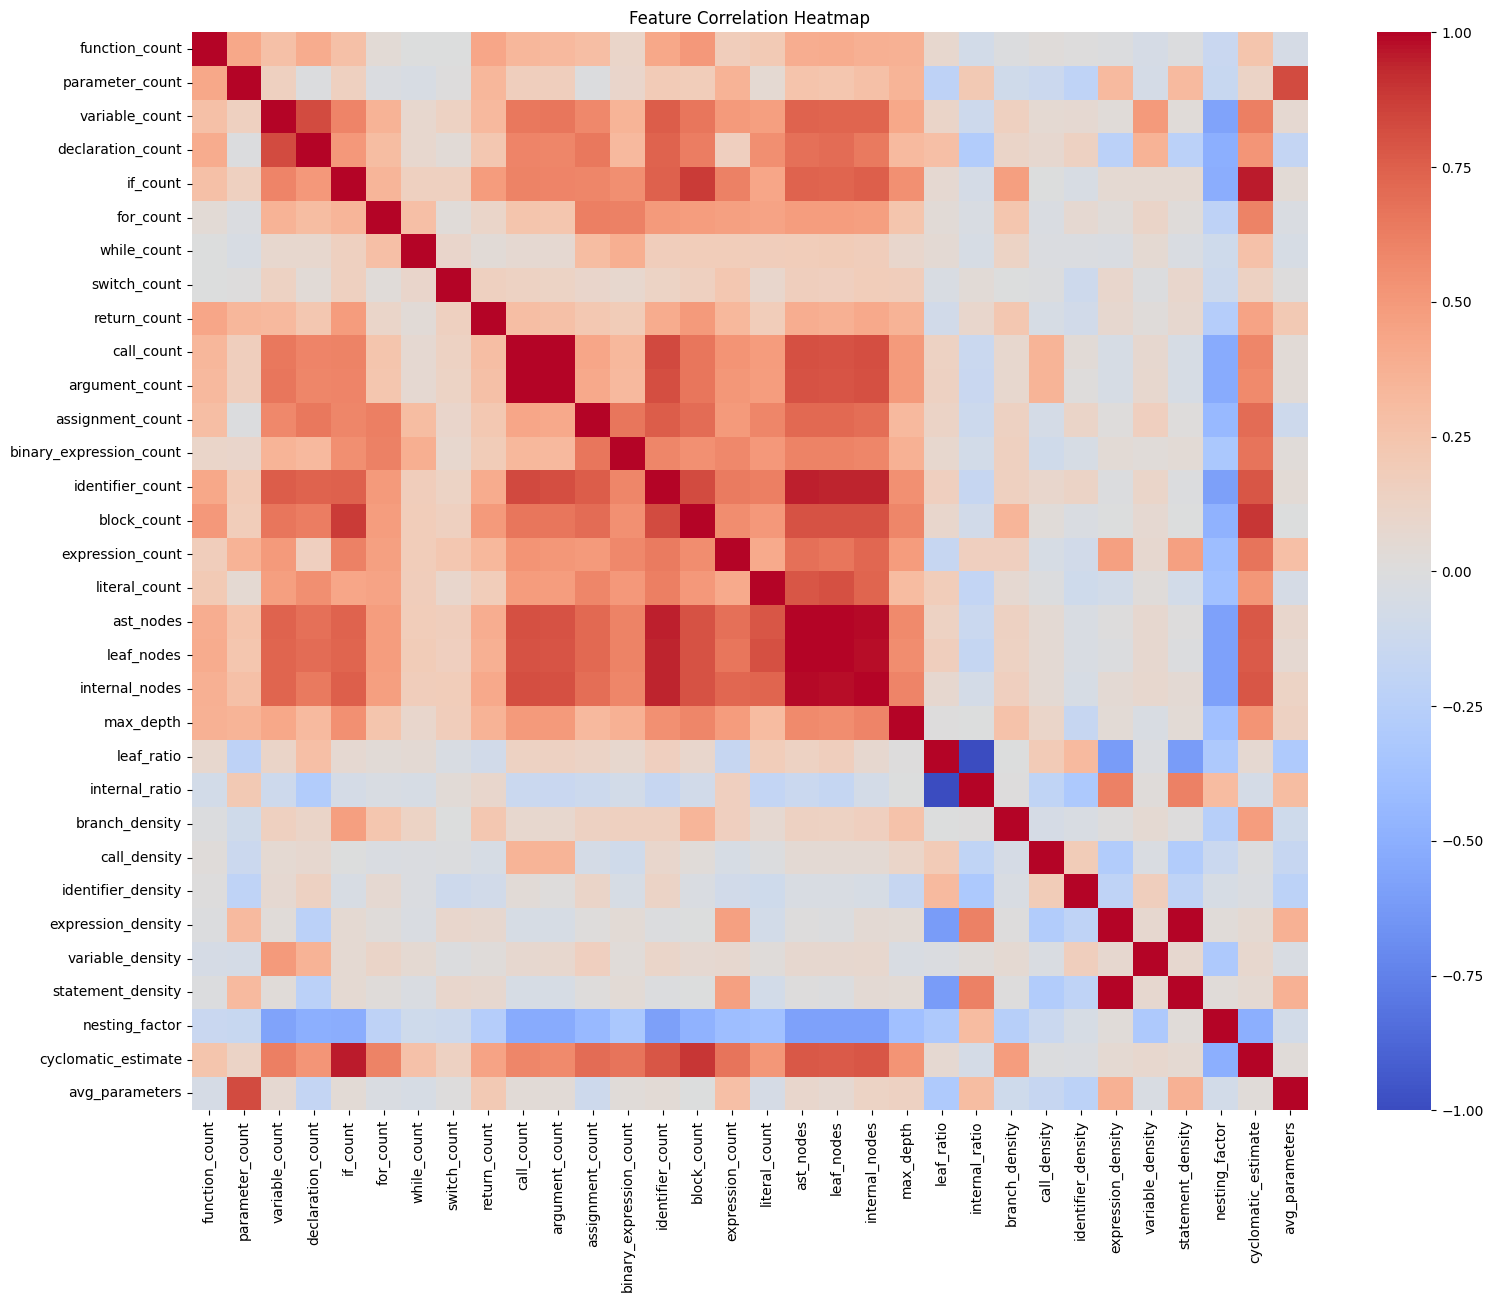

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = features_df.select_dtypes(include="number")

corr = numeric_df.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()